# EE 446 TinyML – Lab 6: Quantized Autoencoder for Anomaly Detection on Arduino Nano 33 BLE Sense

## Overview

In this lab, you will build an autoencoder-based anomaly detector for motion sensor data and prepare the trained model for deployment on the Arduino Nano 33 BLE Sense Rev2.

The model is trained to reconstruct normal activity windows. During inference, windows with high reconstruction error are classified as anomalies.

This notebook is designed for the `tinyml-arduino` Python environment used in this class. Most of the code is provided. Complete only the lines marked with `TODO`.

## Learning Objectives

By the end of this lab, you should be able to:

- Convert IMU time-series data into fixed-length model inputs.
- Visualize windowed sensor data using PCA, t-SNE, and UMAP.
- Train a quantization-aware autoencoder for anomaly detection.
- Select an anomaly threshold using reconstruction error.
- Convert the model to full int8 TensorFlow Lite format.
- Export the model as `autoencoder_model.cc` for Arduino deployment.

## Required File

Place the following file in the same directory as this notebook:

```text
mHealth_subject6.log
```

## Running This Notebook Locally

Activate the class environment and launch JupyterLab from a terminal:

```bash
source ~/ai/projects/tinyml-arduino/bin/activate
jupyter lab
```

In JupyterLab, open this notebook and select:

```text
Kernel -> Change Kernel -> Python (tinyml-arduino)
```

The first code cell checks for missing packages and installs only the missing ones into the active kernel. It does not uninstall or replace the class environment.

In [1]:
# Environment and dependency check
# Run this cell first. It installs only packages that are missing from the active kernel.

import importlib.util
import os
import subprocess
import sys

os.environ["KERAS_BACKEND"] = "tensorflow"

required_packages = {
    "numpy": "numpy<2",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow==2.14.1",
    "keras": "keras==2.14.0",
    "tensorflow_model_optimization": "tensorflow-model-optimization==0.8.0",
    "umap": "umap-learn",
}

packages_to_install = []
for module_name, package_spec in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        packages_to_install.append(package_spec)

try:
    import numpy as _np
    if int(_np.__version__.split(".")[0]) >= 2:
        packages_to_install.append("numpy<2")
except Exception:
    pass

if packages_to_install:
    print("Installing missing packages:", packages_to_install)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *packages_to_install])
    print("Package installation complete. If TensorFlow or NumPy was installed or changed, restart the kernel and rerun the notebook.")
else:
    print("All required packages are available in the active kernel.")

All required packages are available in the active kernel.


In [2]:
# Core imports and reproducibility settings

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import umap.umap_ as umap

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("TF-MOT:", tfmot.__version__)

/Users/student/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.14.1
TF-MOT: 0.8.0


## TODO 1: Load, Prepare, and Window the Sensor Data

This section prepares the mHealth data for model training.

Use the left ankle accelerometer channels from `mHealth_subject6.log`:

- Columns 6, 7, and 8 in the original file, indexed as `5`, `6`, and `7` in Python.
- Column 24 in the original file, indexed as `23` in Python, is the activity label.

Rows with label `0` are removed because they correspond to unlabeled or no-activity segments.

Complete the marked lines to:

1. Select the accelerometer columns and label column.
2. Convert each activity segment into fixed-length windows.
3. Define the normal activity group for binary anomaly detection.

In [3]:
# Parameters
DATA_PATH = Path("mHealth_subject6.log")
WINDOW_SIZE = 100
STRIDE = 1
TRAIN_FRACTION = 0.70

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "mHealth_subject6.log was not found. Place the file in the same directory as this notebook and rerun this cell."
    )

# Load dataset
df = pd.read_csv(DATA_PATH, sep="\t", header=None)

# TODO 1A: Select the left ankle accelerometer columns and label column.
FEATURE_COLUMNS = [5, 6, 7]  # left-ankle accel X,Y,Z (orig cols 6,7,8)
LABEL_COLUMN = 23           # activity label (orig col 24)

if FEATURE_COLUMNS is None or LABEL_COLUMN is None:
    raise NotImplementedError("Complete TODO 1A: set FEATURE_COLUMNS and LABEL_COLUMN.")

# Remove unlabeled rows
filtered_df = df[df[LABEL_COLUMN] > 0].copy()

# Extract accelerometer features and convert labels to zero-based indexing
X_all = filtered_df[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
y_all = filtered_df[LABEL_COLUMN].to_numpy(dtype=np.int32) - 1

label_map = {
    0: "Standing still",
    1: "Sitting and relaxing",
    2: "Lying down",
    3: "Walking",
    4: "Climbing stairs",
    5: "Waist bends forward",
    6: "Frontal elevation of arms",
    7: "Knees bending",
    8: "Cycling",
    9: "Jogging",
    10: "Running",
    11: "Jumping",
}


def create_windows(sequence, label, window_size=WINDOW_SIZE, stride=STRIDE):
    windows = []
    labels = []

    for start in range(0, len(sequence) - window_size + 1, stride):
        # TODO 1B: Extract a 100 x 3 window and flatten it into a 300-dimensional vector.
        window = sequence[start:start + window_size].flatten()

        if window is None:
            raise NotImplementedError("Complete TODO 1B: create and flatten each sensor window.")

        windows.append(window)
        labels.append(label)

    return windows, labels


X_train_windows, X_test_windows = [], []
y_train_labels, y_test_labels = [], []

# Split each activity class temporally before windowing
for label in sorted(np.unique(y_all)):
    class_sequence = X_all[y_all == label]
    split_idx = int(TRAIN_FRACTION * len(class_sequence))

    train_sequence = class_sequence[:split_idx]
    test_sequence = class_sequence[split_idx:]

    train_windows, train_labels = create_windows(train_sequence, label)
    test_windows, test_labels = create_windows(test_sequence, label)

    X_train_windows.extend(train_windows)
    y_train_labels.extend(train_labels)
    X_test_windows.extend(test_windows)
    y_test_labels.extend(test_labels)

X_train = np.asarray(X_train_windows, dtype=np.float32)
X_test = np.asarray(X_test_windows, dtype=np.float32)
y_train = np.asarray(y_train_labels, dtype=np.int32)
y_test = np.asarray(y_test_labels, dtype=np.int32)

# TODO 1C: Define the normal activity labels for this lab.
# Normal group: standing, sitting, lying down, waist bends, frontal arm elevation, and knees bending.
NORMAL_LABELS = [0, 1, 2, 5, 6, 7]  # standing, sitting, lying, waist bends, frontal arm elev, knees bending

if NORMAL_LABELS is None:
    raise NotImplementedError("Complete TODO 1C: define NORMAL_LABELS.")


def to_binary_label(labels, normal_labels=NORMAL_LABELS):
    return np.where(np.isin(labels, normal_labels), 0, 1).astype(np.int32)


y_train_binary = to_binary_label(y_train)
y_test_binary = to_binary_label(y_test)

X_train_binary = X_train.copy()
X_test_binary = X_test.copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Training activity distribution:", np.bincount(y_train))
print("Testing activity distribution:", np.bincount(y_test))
print("Training binary distribution [normal, anomaly]:", np.bincount(y_train_binary))
print("Testing binary distribution [normal, anomaly]:", np.bincount(y_test_binary))

X_train shape: (21350, 300)
X_test shape: (8479, 300)
y_train shape: (21350,)
y_test shape: (8479,)
Training activity distribution: [2051 2051 2051 2051 2051 1442 1370 1513 2051 2051 2051  617]
Testing activity distribution: [823 823 823 823 823 562 531 593 823 823 823 209]
Training binary distribution [normal, anomaly]: [10478 10872]
Testing binary distribution [normal, anomaly]: [4155 4324]


## TODO 2: Visualize the Prepared Data

This section visualizes the windowed IMU data using UMAP, PCA, and t-SNE.

These visualizations are not used directly by the model. They help inspect whether activity windows form meaningful structure before training the anomaly detector.

Include the PCA, t-SNE, and UMAP plots in `Lab6_Report.pdf`.

In [4]:
# Prepare a fixed visualization subset
MAX_VIS_POINTS = 5000

if len(X_test) > MAX_VIS_POINTS:
    rng = np.random.default_rng(42)
    vis_idx = rng.choice(len(X_test), size=MAX_VIS_POINTS, replace=False)
else:
    vis_idx = np.arange(len(X_test))

X_vis = X_test[vis_idx]
y_vis = y_test[vis_idx]
unique_vis_labels = sorted(np.unique(y_vis))

cmap = plt.get_cmap("tab20")
colors = {label: cmap(i % 20) for i, label in enumerate(unique_vis_labels)}

print("Visualization subset shape:", X_vis.shape)


def plot_2d_projection(X_proj, title, xlabel, ylabel):
    plt.figure(figsize=(12, 6))

    for label in unique_vis_labels:
        idx = y_vis == label
        plt.scatter(
            X_proj[idx, 0],
            X_proj[idx, 1],
            s=5,
            color=colors[label],
            label=label_map[label],
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(markerscale=3, fontsize=9, title="Activity", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Visualization subset shape: (5000, 300)


### TODO 2: Visualize the Prepared Data Using PCA, t-SNE, and UMAP

In this section, you will create three 2D visualizations of the prepared windowed sensor data:

1. PCA  
2. t-SNE  
3. UMAP  

Use the prepared feature matrix as the input. Each row should represent one sensor window, and each column should represent one feature from the flattened accelerometer window.

For each method:

- Set the number of output dimensions to 2.
- Use `random_state=42` where supported.
- Plot the two-dimensional embedding using the binary labels to color normal and anomalous windows.
- Add clear axis labels, a title, and a legend.

Useful documentation:

- [PCA documentation — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [t-SNE documentation — scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
- [UMAP documentation — umap-learn](https://umap-learn.readthedocs.io/)

Notes:

PCA is a linear dimensionality reduction method that projects high-dimensional data into a lower-dimensional space. t-SNE and UMAP are nonlinear methods commonly used for visualizing high-dimensional data. These plots should be used as exploratory visualizations rather than final proof that the classes are perfectly separable.

/Users/student/ai/projects/tinyml-arduino/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


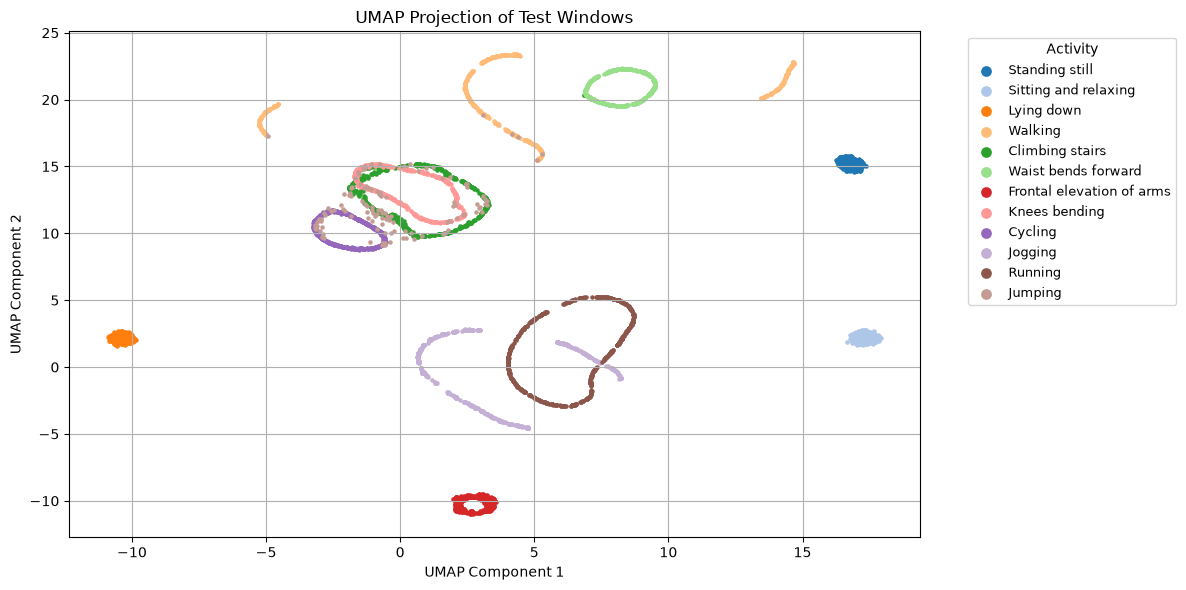

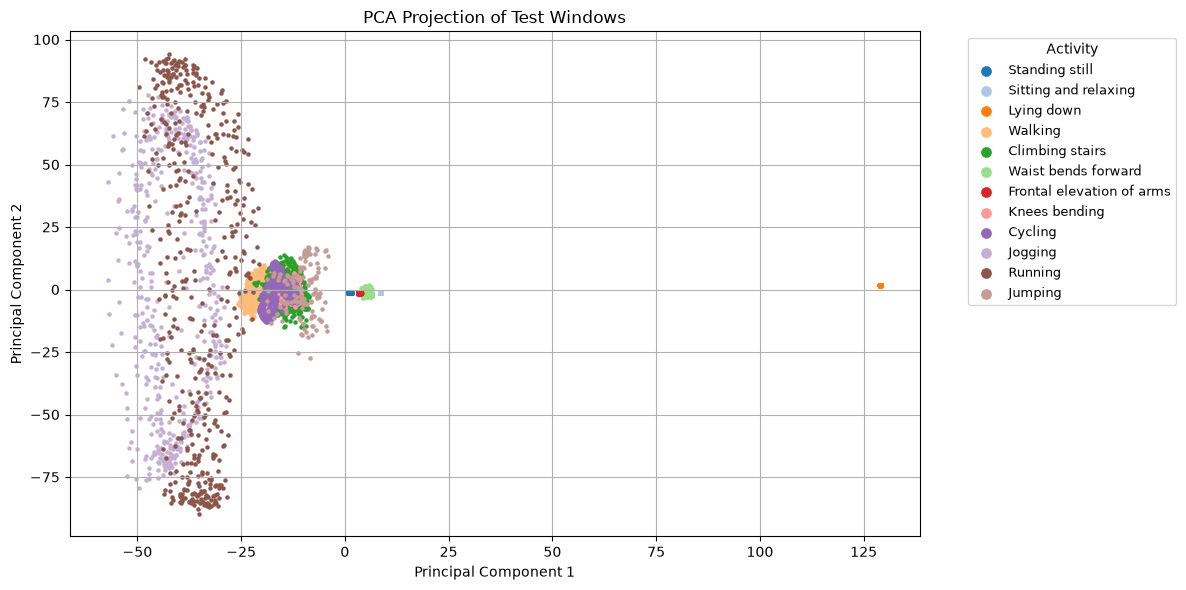

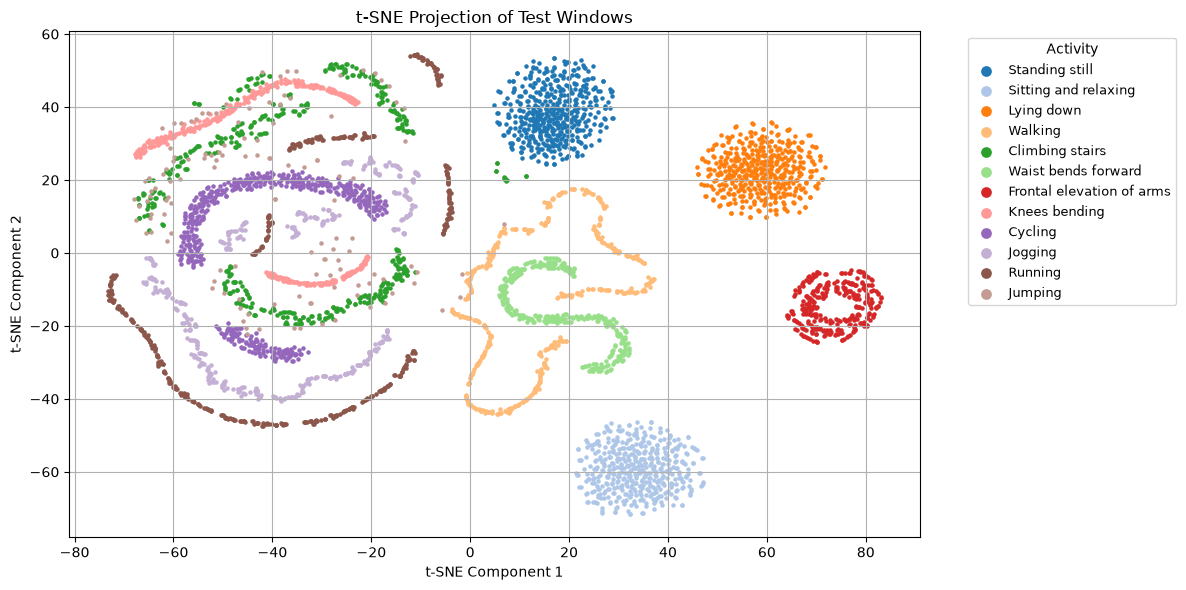

In [5]:
# TODO 2: Generate UMAP, PCA, and t-SNE projections.

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
)

# TODO 2A: Fit UMAP on X_vis.
X_umap = umap_model.fit_transform(X_vis)

# TODO 2B: Fit PCA with two components on X_vis.
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_vis)

# TODO 2C: Fit t-SNE with two components on X_vis.
tsne_kwargs = dict(
    n_components=2,
    perplexity=30,
    learning_rate=300,
    random_state=42,
)

X_tsne = TSNE(**tsne_kwargs).fit_transform(X_vis)

if X_umap is None or X_pca is None or X_tsne is None:
    raise NotImplementedError("Complete TODO 2: generate X_umap, X_pca, and X_tsne.")

plot_2d_projection(X_umap, "UMAP Projection of Test Windows", "UMAP Component 1", "UMAP Component 2")
plot_2d_projection(X_pca, "PCA Projection of Test Windows", "Principal Component 1", "Principal Component 2")
plot_2d_projection(X_tsne, "t-SNE Projection of Test Windows", "t-SNE Component 1", "t-SNE Component 2")

## TODO 3: Train the Quantization-Aware Autoencoder

The anomaly detector is based on reconstruction error.

The autoencoder is trained only on normal activity windows. The main assumption is that the model reconstructs normal windows well, while anomalous windows produce larger reconstruction errors.

Complete the marked lines to:

1. Select only normal training windows.
2. Define the bottleneck and output layers.
3. Train the float32 autoencoder.
4. Apply quantization-aware training.

Model: "anomaly_autoencoder"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_1 (InputLayer)        [(None, 300)]             0         


 dense (Dense)               (None, 32)                9632      


...

37/37 [==============================] - 0s 3ms/step - loss: 0.0584 - val_loss: 0.5258


Epoch 100/100


 1/37 [..............................] - ETA: 0s - loss: 0.0696

22/37 [================>.............] - ETA: 0s - loss: 0.0569

37/37 [==============================] - 0s 3ms/step - loss: 0.0585 - val_loss: 0.5250


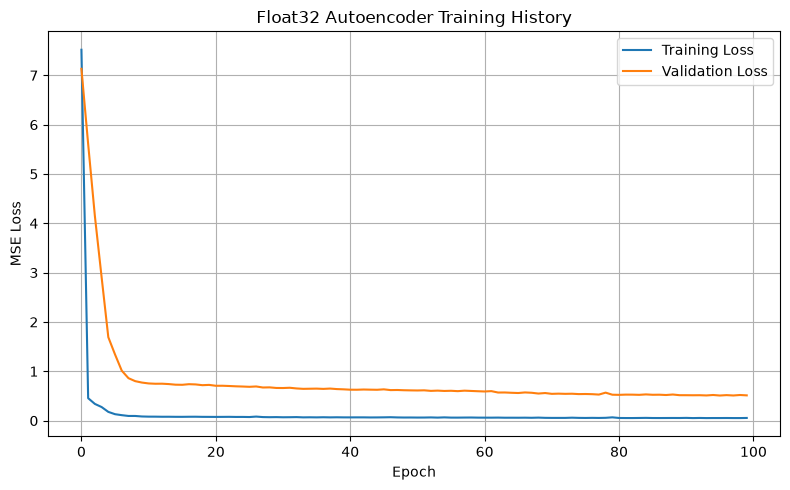

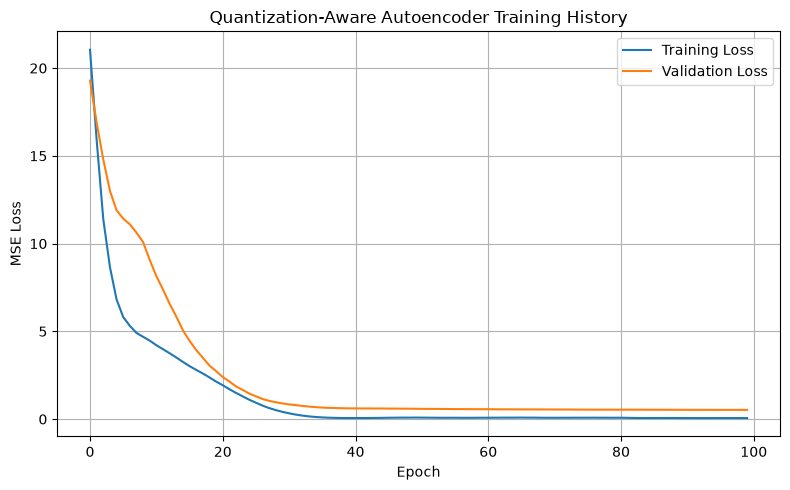

In [6]:
# TODO 3A: Select only normal windows for autoencoder training.
X_train_normal = X_train_binary[y_train_binary == 0]

if X_train_normal is None:
    raise NotImplementedError("Complete TODO 3A: select normal training windows.")

input_dim = X_train_normal.shape[1]
latent_dim = 16

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu")(input_layer)

# TODO 3B: Add a latent/bottleneck layer with latent_dim units.
latent = Dense(latent_dim, activation="relu")(encoded)

if latent is None:
    raise NotImplementedError("Complete TODO 3B: define the latent layer.")

decoded = Dense(32, activation="relu")(latent)

# TODO 3C: Add the output layer that reconstructs the full input window.
output_layer = Dense(input_dim, activation="linear")(decoded)

if output_layer is None:
    raise NotImplementedError("Complete TODO 3C: define the output layer.")

autoencoder = Model(inputs=input_layer, outputs=output_layer, name="anomaly_autoencoder")
autoencoder.compile(optimizer=Adam(learning_rate=0.005), loss="mse")
autoencoder.summary()

EPOCHS = 100
BATCH_SIZE = 256

history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,
    verbose=1,
)

# Apply quantization-aware training to the trained autoencoder.
q_aware_autoencoder = tfmot.quantization.keras.quantize_model(autoencoder)
q_aware_autoencoder.compile(optimizer=Adam(learning_rate=0.0001), loss="mse")

qat_history = q_aware_autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,
    verbose=1,
)


def plot_training_history(training_history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(training_history.history["loss"], label="Training Loss")
    plt.plot(training_history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_training_history(history, "Float32 Autoencoder Training History")
plot_training_history(qat_history, "Quantization-Aware Autoencoder Training History")


def reconstruction_errors(model, X, batch_size=512):
    recon = model.predict(X, batch_size=batch_size, verbose=0)
    return np.mean((X - recon) ** 2, axis=1)

## TODO 4: Perform Reconstruction Error-Based Anomaly Detection

This section converts reconstruction error into a binary anomaly decision.

Complete the threshold value after inspecting the reconstruction error distributions. A larger threshold usually reduces false positives but may miss anomalies. A smaller threshold may detect more anomalies but can increase false positives.

Include the reconstruction error plot, selected threshold, confusion matrix, and classification report in `Lab6_Report.pdf`.

Train normal       mean=0.105106, stderr=0.001656, min=0.009276, max=1.105015
Train anomaly      mean=42.685780, stderr=0.375971, min=2.232911, max=130.293076
Test normal        mean=0.145316, stderr=0.003961, min=0.010784, max=1.377963
Test anomaly       mean=43.007214, stderr=0.628077, min=2.529424, max=134.936432


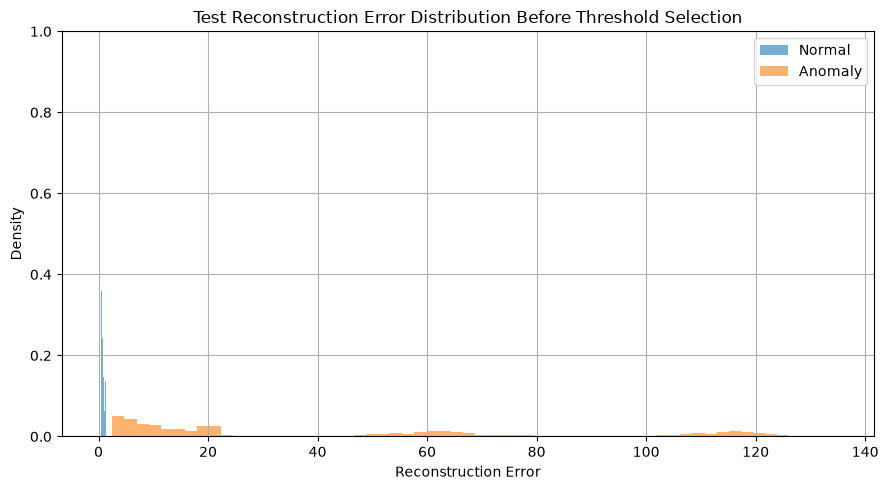

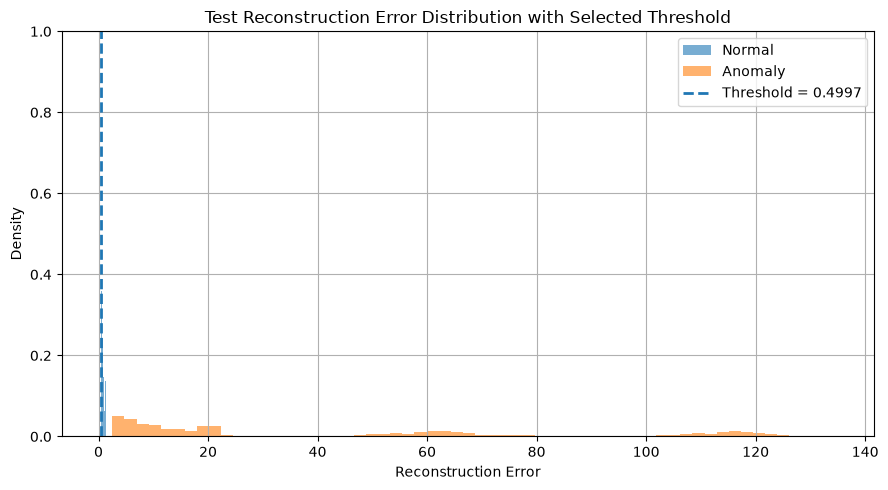

Train set evaluation
              precision    recall  f1-score   support

  Normal (0)       1.00      0.95      0.97     10478
 Anomaly (1)       0.95      1.00      0.98     10872

    accuracy                           0.98     21350
   macro avg       0.98      0.97      0.98     21350
weighted avg       0.98      0.98      0.98     21350

Test set evaluation
              precision    recall  f1-score   support

  Normal (0)       1.00      0.87      0.93      4155
 Anomaly (1)       0.89      1.00      0.94      4324

    accuracy                           0.94      8479
   macro avg       0.94      0.94      0.94      8479
weighted avg       0.94      0.94      0.94      8479



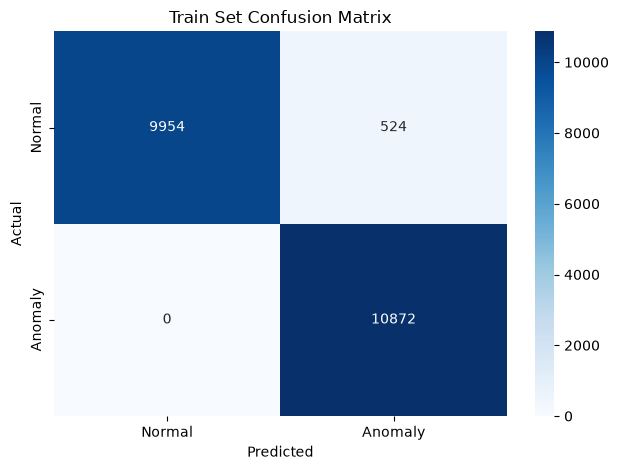

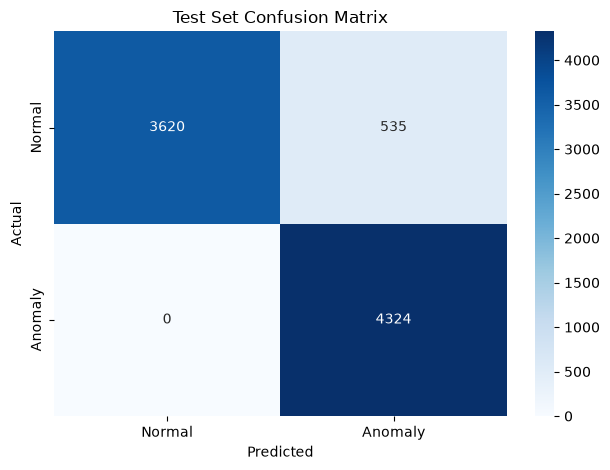

In [7]:
# Compute reconstruction errors using the quantization-aware autoencoder.
train_errors = reconstruction_errors(q_aware_autoencoder, X_train_binary)
test_errors = reconstruction_errors(q_aware_autoencoder, X_test_binary)

train_normal_errors = train_errors[y_train_binary == 0]
train_anomaly_errors = train_errors[y_train_binary == 1]
test_normal_errors = test_errors[y_test_binary == 0]
test_anomaly_errors = test_errors[y_test_binary == 1]


def summarize_errors(name, errors):
    print(
        f"{name:<18} mean={np.mean(errors):.6f}, "
        f"stderr={np.std(errors) / np.sqrt(len(errors)):.6f}, "
        f"min={np.min(errors):.6f}, max={np.max(errors):.6f}"
    )


summarize_errors("Train normal", train_normal_errors)
summarize_errors("Train anomaly", train_anomaly_errors)
summarize_errors("Test normal", test_normal_errors)
summarize_errors("Test anomaly", test_anomaly_errors)


def plot_reconstruction_error_distribution(normal_errors, anomaly_errors, threshold=None, title="Reconstruction Error Distribution"):
    plt.figure(figsize=(9, 5))
    plt.hist(normal_errors, bins=60, alpha=0.6, label="Normal", density=True)
    plt.hist(anomaly_errors, bins=60, alpha=0.6, label="Anomaly", density=True)

    if threshold is not None:
        plt.axvline(threshold, linestyle="--", linewidth=2, label=f"Threshold = {threshold:.4f}")

    plt.xlabel("Reconstruction Error")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


plot_reconstruction_error_distribution(
    test_normal_errors,
    test_anomaly_errors,
    threshold=None,
    title="Test Reconstruction Error Distribution Before Threshold Selection",
)

# TODO 4: Choose a reconstruction-error threshold after inspecting the distributions.
threshold = float(np.percentile(train_normal_errors, 95))

if threshold is None:
    raise NotImplementedError("Complete TODO 4: choose a reconstruction-error threshold.")

y_train_pred = (train_errors > threshold).astype(np.int32)
y_test_pred = (test_errors > threshold).astype(np.int32)

plot_reconstruction_error_distribution(
    test_normal_errors,
    test_anomaly_errors,
    threshold=threshold,
    title="Test Reconstruction Error Distribution with Selected Threshold",
)

print("Train set evaluation")
print(classification_report(y_train_binary, y_train_pred, target_names=["Normal (0)", "Anomaly (1)"]))

print("Test set evaluation")
print(classification_report(y_test_binary, y_test_pred, target_names=["Normal (0)", "Anomaly (1)"]))


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_train_binary, y_train_pred, "Train Set Confusion Matrix")
plot_confusion_matrix(y_test_binary, y_test_pred, "Test Set Confusion Matrix")

## TODO 5: Convert and Export the Model for Arduino Deployment

This section converts the quantization-aware autoencoder into a full int8 TensorFlow Lite model and exports it as a C/C++ source file.

Complete the representative dataset line. The representative dataset is used by the converter to estimate activation ranges for int8 quantization.

The generated file `autoencoder_model.cc` should be placed in the same Arduino sketch folder as `Activity_Anomaly.ino`.

In [8]:
def representative_dataset():
    sample_count = min(1000, len(X_train_normal))

    for i in range(sample_count):
        # TODO 5A: Yield one normal training sample as a float32 batch with shape (1, input_dim).
        sample = X_train_normal[i:i + 1].astype(np.float32)

        if sample is None:
            raise NotImplementedError("Complete TODO 5A: define the representative dataset sample.")

        yield [sample]


converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_autoencoder)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("autoencoder_int8.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved autoencoder_int8.tflite")
print("Model size:", round(len(tflite_model) / 1024, 2), "KB")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmph4fp_2bd/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmph4fp_2bd/assets


/Users/student/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved autoencoder_int8.tflite
Model size: 24.46 KB


2026-07-31 16:22:04.437612: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-31 16:22:04.437648: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-31 16:22:04.438207: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmph4fp_2bd
2026-07-31 16:22:04.440542: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-31 16:22:04.440550: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmph4fp_2bd
2026-07-31 16:22:04.445482: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-31 16:22:04.448178: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-31 16:22:04.532101: I tensorflow/cc/saved_model/loader.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Input quantization: (0.08135765045881271, 18)
Output quantization: (0.08584998548030853, -8)


Train set evaluation: int8 model
              precision    recall  f1-score   support

  Normal (0)       1.00      0.95      0.97     10478
 Anomaly (1)       0.95      1.00      0.98     10872

    accuracy                           0.98     21350
   macro avg       0.98      0.98      0.98     21350
weighted avg       0.98      0.98      0.98     21350

Test set evaluation: int8 model
              precision    recall  f1-score   support

  Normal (0)       1.00      0.87      0.93      4155
 Anomaly (1)       0.89      1.00      0.94      4324

    accuracy                           0.94      8479
   macro avg       0.94      0.94      0.94      8479
weighted avg       0.94      0.94      0.94      8479



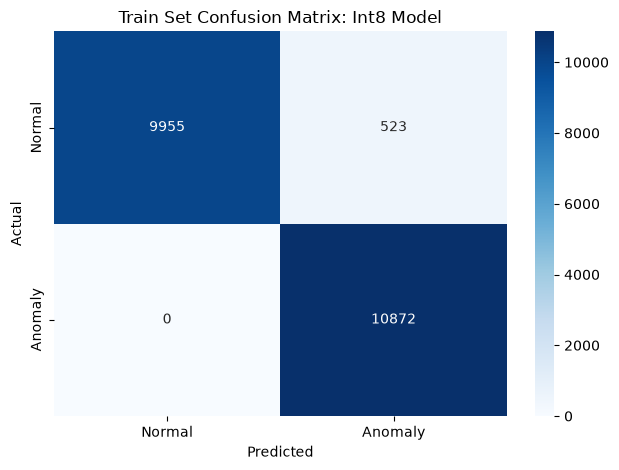

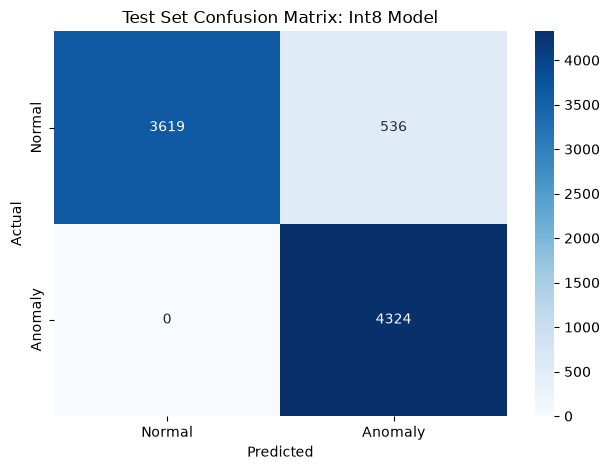

In [9]:
# Test the quantized TFLite model in Python before deploying to Arduino.

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("Input quantization:", input_details[0]["quantization"])
print("Output quantization:", output_details[0]["quantization"])


def evaluate_quantized_reconstruction_error(X):
    errors = []

    for x in X:
        x_quantized = np.round(x / input_scale + input_zero_point)
        x_quantized = np.clip(x_quantized, -128, 127).astype(np.int8).reshape(1, -1)

        interpreter.set_tensor(input_details[0]["index"], x_quantized)
        interpreter.invoke()

        y_pred_quantized = interpreter.get_tensor(output_details[0]["index"])
        y_pred = (y_pred_quantized.astype(np.float32) - output_zero_point) * output_scale

        errors.append(np.mean((x - y_pred[0]) ** 2))

    return np.asarray(errors, dtype=np.float32)


train_errors_int8 = evaluate_quantized_reconstruction_error(X_train_binary)
test_errors_int8 = evaluate_quantized_reconstruction_error(X_test_binary)

y_train_pred_int8 = (train_errors_int8 > threshold).astype(np.int32)
y_test_pred_int8 = (test_errors_int8 > threshold).astype(np.int32)

print("Train set evaluation: int8 model")
print(classification_report(y_train_binary, y_train_pred_int8, target_names=["Normal (0)", "Anomaly (1)"]))

print("Test set evaluation: int8 model")
print(classification_report(y_test_binary, y_test_pred_int8, target_names=["Normal (0)", "Anomaly (1)"]))

plot_confusion_matrix(y_train_binary, y_train_pred_int8, "Train Set Confusion Matrix: Int8 Model")
plot_confusion_matrix(y_test_binary, y_test_pred_int8, "Test Set Confusion Matrix: Int8 Model")

In [10]:
# Estimate tensor memory and compare model sizes.

tensor_details = interpreter.get_tensor_details()
total_tensor_bytes = 0

for tensor in tensor_details:
    shape = tensor["shape"]
    dtype = tensor["dtype"]
    num_elements = np.prod(shape)
    total_tensor_bytes += num_elements * np.dtype(dtype).itemsize

print(f"Estimated tensor memory: {total_tensor_bytes / 1024:.2f} KB")

# Save a float32 TFLite model for size comparison.
converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(autoencoder)
tflite_model_fp32 = converter_fp32.convert()

with open("autoencoder_fp32.tflite", "wb") as f:
    f.write(tflite_model_fp32)


def file_size_kb(path):
    return round(Path(path).stat().st_size / 1024, 2)


model_paths = {
    "Float32 TFLite": "autoencoder_fp32.tflite",
    "Full int8 TFLite": "autoencoder_int8.tflite",
}

print("TFLite model size comparison")
for model_name, model_path in model_paths.items():
    print(f"{model_name:<18}: {file_size_kb(model_path)} KB")

Estimated tensor memory: 21.90 KB


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmphtp4kbgu/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmphtp4kbgu/assets


2026-07-31 16:22:06.049259: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-31 16:22:06.049273: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


TFLite model size comparison
Float32 TFLite    : 82.87 KB
Full int8 TFLite  : 24.46 KB


2026-07-31 16:22:06.049449: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmphtp4kbgu
2026-07-31 16:22:06.050420: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-31 16:22:06.050428: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmphtp4kbgu
2026-07-31 16:22:06.053258: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-31 16:22:06.101282: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmphtp4kbgu
2026-07-31 16:22:06.115086: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 65638 microseconds.


In [11]:
# Convert the int8 TFLite model into a C/C++ array for Arduino.

def convert_tflite_to_c_array(tflite_path, output_cc_path, array_name="g_model"):
    tflite_data = Path(tflite_path).read_bytes()

    with open(output_cc_path, "w") as f:
        f.write(f"const unsigned char {array_name}[] = {{\n")

        for i, byte in enumerate(tflite_data):
            if i % 12 == 0:
                f.write("  ")
            f.write(f"0x{byte:02x}, ")
            if (i + 1) % 12 == 0:
                f.write("\n")

        f.write("\n};\n")
        f.write(f"const int {array_name}_len = {len(tflite_data)};\n")

    print(f"Saved {output_cc_path}")
    print(f"Array name: {array_name}")
    print(f"Model bytes: {len(tflite_data)}")


convert_tflite_to_c_array("autoencoder_int8.tflite", "autoencoder_model.cc")

Saved autoencoder_model.cc
Array name: g_model
Model bytes: 25048


## Arduino Deployment Sketch

Create a folder named `Activity_Anomaly`. Place the following two files inside that folder:

```text
Activity_Anomaly/
├── Activity_Anomaly.ino
└── autoencoder_model.cc
```

The sketch below is written for Arduino Nano 33 BLE Sense Rev2 using the `Arduino_BMI270_BMM150` library.

Before uploading, replace the threshold value in the sketch with the threshold selected in this notebook.

```cpp
#include "TensorFlowLite.h"
#include "autoencoder_model.cc"

#include "tensorflow/lite/micro/all_ops_resolver.h"
#include "tensorflow/lite/micro/micro_error_reporter.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"
#include "tensorflow/lite/version.h"

#include <Arduino_BMI270_BMM150.h>
#include <math.h>

tflite::MicroErrorReporter micro_error_reporter;
tflite::ErrorReporter* error_reporter = &micro_error_reporter;

const int kWindowSize = 100;
const int kInputSize = 300;
const int kTensorArenaSize = 64 * 1024;
uint8_t tensor_arena[kTensorArenaSize];

float window_buffer[kWindowSize][3];
int sample_index = 0;
bool window_filled = false;

tflite::MicroInterpreter* interpreter;
TfLiteTensor* input;
TfLiteTensor* output;

float input_scale;
int input_zero_point;
float output_scale;
int output_zero_point;

// Replace this value with the threshold selected in Python.
const float kReconstructionErrorThreshold = 1.5;

void setup() {
  Serial.begin(115200);
  while (!Serial);

  if (!IMU.begin()) {
    Serial.println("Failed to initialize IMU.");
    while (1);
  }

  Serial.println("IMU initialized.");

  const tflite::Model* model = tflite::GetModel(g_model);

  if (model->version() != TFLITE_SCHEMA_VERSION) {
    Serial.println("Model schema version mismatch.");
    while (1);
  }

  static tflite::AllOpsResolver resolver;

  static tflite::MicroInterpreter static_interpreter(
    model,
    resolver,
    tensor_arena,
    kTensorArenaSize,
    error_reporter
  );

  interpreter = &static_interpreter;

  if (interpreter->AllocateTensors() != kTfLiteOk) {
    Serial.println("AllocateTensors failed.");
    while (1);
  }

  input = interpreter->input(0);
  output = interpreter->output(0);

  input_scale = input->params.scale;
  input_zero_point = input->params.zero_point;
  output_scale = output->params.scale;
  output_zero_point = output->params.zero_point;

  Serial.println("Model setup complete.");
}

void loop() {
  float x, y, z;

  if (IMU.accelerationAvailable()) {
    IMU.readAcceleration(x, y, z);

    window_buffer[sample_index][0] = x;
    window_buffer[sample_index][1] = y;
    window_buffer[sample_index][2] = z;

    sample_index++;

    if (sample_index >= kWindowSize) {
      sample_index = 0;
      window_filled = true;
    }

    if (window_filled) {
      for (int i = 0; i < kWindowSize; i++) {
        for (int j = 0; j < 3; j++) {
          float val = window_buffer[i][j];
          int index = i * 3 + j;

          int32_t q = lround(val / input_scale) + input_zero_point;
          q = constrain(q, -128, 127);

          input->data.int8[index] = static_cast<int8_t>(q);
        }
      }

      if (interpreter->Invoke() != kTfLiteOk) {
        Serial.println("Inference failed.");
        return;
      }

      float recon_error = 0.0;

      for (int i = 0; i < kInputSize; i++) {
        float original = window_buffer[i / 3][i % 3];

        int8_t quant_pred = output->data.int8[i];
        float predicted = (quant_pred - output_zero_point) * output_scale;

        float diff = original - predicted;
        recon_error += diff * diff;
      }

      recon_error /= kInputSize;

      Serial.print("Reconstruction error: ");
      Serial.println(recon_error, 6);

      if (recon_error > kReconstructionErrorThreshold) {
        Serial.println("Result: Anomaly detected");
      } else {
        Serial.println("Result: Normal activity");
      }
    }
  }

  delay(20);
}
```

## Report and Submission Reminder

Submit one public GitHub link through Canvas. The link should point directly to the Lab 6 folder.

The Lab 6 folder should contain:

```text
Lab6_TinyML_Anomaly_Detection/
├── Lab6_Report.pdf
├── TinyML_Lab6.ipynb
└── Activity_Anomaly/
    ├── Activity_Anomaly.ino
    └── autoencoder_model.cc
```

Include the public Edge Impulse project link inside `Lab6_Report.pdf`.

For Part 2, include the following in the report:

1. Training and validation loss curves.
2. PCA, t-SNE, and UMAP visualizations.
3. Reconstruction error distribution and selected threshold.
4. Confusion matrix and classification report.
5. Arduino serial monitor output showing reconstruction error and normal/anomaly detection result.
6. Short answers to the discussion questions listed in the submission guidelines.